In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
pd.set_option('display.max_columns', None)
dfInit = pd.read_csv('./student_lifestyle_dataset.csv', delimiter=',', encoding='utf-8')
df = dfInit.copy(deep=True)
display(df)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78
...,...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,Moderate,Male,8.30
1996,1997,6.3,2.8,8.8,1.5,4.6,Moderate,Female,6.62
1997,1998,6.2,0.0,6.2,0.8,10.8,Moderate,Male,7.85
1998,1999,8.1,0.7,7.6,3.5,4.1,High,Male,7.60


In [30]:
genderDict = { "Male" : 0, "Female" : 1 }
stressDict = {"Low" : 0, "High" : 1, "Moderate" : 2}
df["Gender"] = df["Gender"].map(lambda elem : genderDict[elem])
df["Stress_Level"] = df["Stress_Level"].map(lambda elem : stressDict[elem])
display(df)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,2,0,7.48
1,2,5.3,3.5,8.0,4.2,3.0,0,1,6.88
2,3,5.1,3.9,9.2,1.2,4.6,0,0,6.68
3,4,6.5,2.1,7.2,1.7,6.5,2,0,7.20
4,5,8.1,0.6,6.5,2.2,6.6,1,0,8.78
...,...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,2,0,8.30
1996,1997,6.3,2.8,8.8,1.5,4.6,2,1,6.62
1997,1998,6.2,0.0,6.2,0.8,10.8,2,0,7.85
1998,1999,8.1,0.7,7.6,3.5,4.1,1,0,7.60


In [31]:
X = df.drop('Stress_Level', axis=1).values
y = df['Stress_Level'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
feature_len = X_scaled.shape[1]
side_len = int(np.ceil(np.sqrt(feature_len)))
padding = side_len ** 2 - feature_len
X_padded = np.pad(X_scaled, ((0, 0), (0, padding)), 'constant')
X_reshaped = X_padded.reshape(-1, 1, side_len, side_len)
display(X_reshaped)

array([[[[-1.731185  , -0.40448677,  1.56624592],
         [ 0.82073377,  0.05654313, -1.00589562],
         [-0.98412598, -0.41498681,  0.        ]]],


       [[[-1.72945295, -1.52845139,  1.30663281],
         [ 0.34147317,  0.88588186, -0.52847018],
         [ 1.01613007, -1.21864076,  0.        ]]],


       [[[-1.7277209 , -1.66894696,  1.65278363],
         [ 1.16306277, -0.89127256,  0.10809708],
         [-0.98412598, -1.48652541,  0.        ]]],


       ...,


       [[[ 1.7277209 , -0.89622129, -1.72218687],
         [-0.89091121, -1.12822648,  2.57479519],
         [-0.98412598,  0.08059979,  0.        ]]],


       [[[ 1.72945295,  0.4384867 , -1.11642293],
         [ 0.06760998,  0.47121249, -0.09083019],
         [-0.98412598, -0.25425602,  0.        ]]],


       [[[ 1.731185  ,  1.0707168 , -0.25104588],
         [-0.13778742,  0.23425857, -0.56825563],
         [-0.98412598,  1.55396537,  0.        ]]]], shape=(2000, 1, 3, 3))

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [35]:
class StressLevelCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * (side_len // 2) * (side_len // 2), 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = StressLevelCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 15
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, loss: {total_loss:.4f}")

Epoch 1, loss: 51.6846
Epoch 2, loss: 46.8671
Epoch 3, loss: 42.8218
Epoch 4, loss: 37.2711
Epoch 5, loss: 32.0030
Epoch 6, loss: 27.7486
Epoch 7, loss: 24.5507
Epoch 8, loss: 21.9865
Epoch 9, loss: 20.4165
Epoch 10, loss: 19.0284
Epoch 11, loss: 17.8073
Epoch 12, loss: 17.0268
Epoch 13, loss: 16.2875
Epoch 14, loss: 15.4448
Epoch 15, loss: 14.7756


In [37]:
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        pred_labels = pred.argmax(dim=1)
        correct += (pred_labels == yb).sum().item()
        total += yb.size(0)
        all_preds.extend(pred_labels.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

print(f"Accuracy : {correct / total:.4f}")

Accuracy : 0.8700


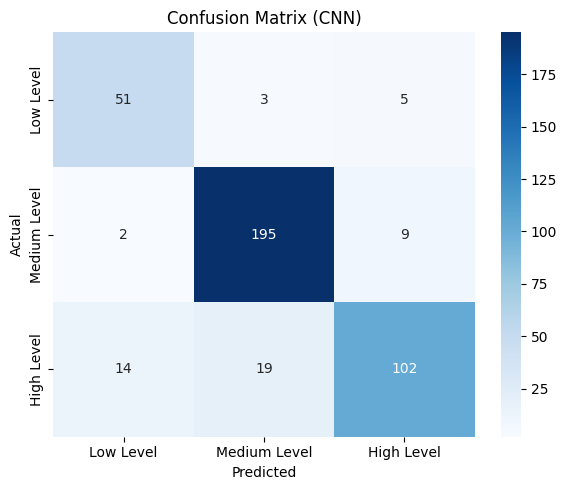

In [38]:
cm = confusion_matrix(all_labels, all_preds)

class_names = ['Low Level', 'Medium Level', "High Level"]
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (CNN)')
plt.tight_layout()
plt.show()